<a href="https://colab.research.google.com/github/77marco/Challenge-TelecomX-AnalisisDeEvasionDeClientes-Parte2/blob/main/TelecomX_Parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#🔧 Preparación de los Datos

## Extracción del Archivo Tratado

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import pandas as pd

# Ruta de acceso que tengo desde el explorador de archivos de google drive donde se guardo el archivo solicitado
ruta = '/content/drive/MyDrive/Data Science /Alura Latam/Cursos/Estadistica y Machine learning/Challenge Telecom X: análisis de evasión de clientes - Parte 2/datos_tratados.csv'

# Cargar el archivo CSV en un DataFrame
df_telecom = pd.read_csv(ruta)

# Visualizar las primeras 5 filas para confirmar que todo está en orden
df_telecom.head()

,customerID,Evasion,gender,SeniorCitizen,Partner,Dependents,Meses_Contrato,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Cargos_Mensuales,Cuentas_Diarias,Cargos_Totales
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,2.19,593.30
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,2.00,542.40
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,2.46,280.85
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,3.27,1237.85
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,2.80,267.40


## Eliminación de Columnas Irrelevantes

In [17]:
# Eliminar la columna 'customerID'
df_telecom = df_telecom.drop(columns=['customerID'])

# Mostrar las primeras filas y la información general para confirmar
print(df_telecom.head())
print("\n--- Información del DataFrame ---")
df_telecom.info()

   Evasion  gender  SeniorCitizen  Partner  Dependents  Meses_Contrato  \
0        0  Female              0        1           1               9   
1        0    Male              0        0           0               9   
2        1    Male              0        0           0               4   
3        1    Male              1        1           0              13   
4        1  Female              1        1           0               3   

   PhoneService MultipleLines InternetService OnlineSecurity  ...  \
0             1            No             DSL             No  ...   
1             1           Yes             DSL             No  ...   
2             1            No     Fiber optic             No  ...   
3             1            No     Fiber optic             No  ...   
4             1            No     Fiber optic             No  ...   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No         Yes         Yes              No    

## Encoding

In [18]:
# Aplicar One-Hot Encoding a todas las variables categóricas
# Usamos drop_first=True para evitar la "trampa de las variables ficticias" (multicolinealidad)
# Usamos dtype=int para que los resultados sean 0 y 1 en lugar de True y False
df_telecom_encoded = pd.get_dummies(df_telecom, drop_first=True, dtype=int)

# Mostrar cómo quedó el nuevo DataFrame
print(df_telecom_encoded.head())

# Ver el nuevo resumen de columnas y tipos de datos
print("\n--- Información del DataFrame Post-Encoding ---")
df_telecom_encoded.info()

   Evasion  SeniorCitizen  Partner  Dependents  Meses_Contrato  PhoneService  \
0        0              0        1           1               9             1   
1        0              0        0           0               9             1   
2        1              0        0           0               4             1   
3        1              1        1           0              13             1   
4        1              1        1           0               3             1   

   PaperlessBilling  Cargos_Mensuales  Cuentas_Diarias  Cargos_Totales  ...  \
0                 1              65.6             2.19          593.30  ...   
1                 0              59.9             2.00          542.40  ...   
2                 1              73.9             2.46          280.85  ...   
3                 1              98.0             3.27         1237.85  ...   
4                 1              83.9             2.80          267.40  ...   

   OnlineBackup_Yes  DeviceProtection_Yes  T

## Verificación de la Proporción de Cancelación (Churn)

In [19]:
# Contar la cantidad exacta de clientes en cada clase (0 = Retenidos, 1 = Cancelaron)
conteo_churn = df_telecom_encoded['Evasion'].value_counts()
print("--- Cantidad de clientes por clase ---")
print(conteo_churn)

# Calcular el porcentaje que representa cada clase
proporcion_churn = df_telecom_encoded['Evasion'].value_counts(normalize=True) * 100
print("\n--- Proporción de clientes por clase (%) ---")
print(proporcion_churn)

--- Cantidad de clientes por clase ---
Evasion
0    5174
1    1869
Name: count, dtype: int64

--- Proporción de clientes por clase (%) ---
Evasion
0    73.463013
1    26.536987
Name: proportion, dtype: float64


## Balanceo de Clases (opcional)

In [20]:
# Importar la librería necesaria para SMOTE
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Separar las variables predictoras (X) de la variable a predecir (y)
X = df_telecom_encoded.drop('Evasion', axis=1)
y = df_telecom_encoded['Evasion']

# 2. Inicializar SMOTE (fijamos el random_state para que el resultado sea reproducible)
smote = SMOTE(random_state=42)

# 3. Aplicar el algoritmo para generar los nuevos datos sintéticos
X_res, y_res = smote.fit_resample(X, y)

# 4. Volver a unir todo en un solo DataFrame para los siguientes pasos
df_telecom_balanceado = pd.concat([X_res, y_res], axis=1)

# Verificar el resultado final
print("--- Nueva distribución de clases tras aplicar SMOTE ---")
print(df_telecom_balanceado['Evasion'].value_counts())

--- Nueva distribución de clases tras aplicar SMOTE ---
Evasion
0    5174
1    5174
Name: count, dtype: int64


## Normalización o Estandarización (si es necesario)

In [21]:
from sklearn.preprocessing import StandardScaler

# 1. Crear una copia del DataFrame balanceado para mantener el historial limpio
df_telecom_escalado = df_telecom_balanceado.copy()

# 2. Definir cuáles son las columnas con valores numéricos grandes/continuos
columnas_numericas = ['Meses_Contrato', 'Cargos_Mensuales', 'Cuentas_Diarias', 'Cargos_Totales']

# 3. Inicializar el escalador
scaler = StandardScaler()

# 4. Aplicar la transformación solo a esas columnas específicas
df_telecom_escalado[columnas_numericas] = scaler.fit_transform(df_telecom_escalado[columnas_numericas])

# 5. Visualizar cómo quedaron los datos transformados
print("--- Variables Numéricas Estandarizadas ---")
print(df_telecom_escalado[columnas_numericas].head())

--- Variables Numéricas Estandarizadas ---
   Meses_Contrato  Cargos_Mensuales  Cuentas_Diarias  Cargos_Totales
0       -0.777727         -0.084757        -0.081271       -0.664633
1       -0.777727         -0.283260        -0.279752       -0.687908
2       -0.986176          0.204290         0.200781       -0.807503
3       -0.610968          1.043573         1.046936       -0.369908
4       -1.027865          0.552540         0.555957       -0.813654


#📊 Correlación y Selección de Variables

## Análisis de Correlación

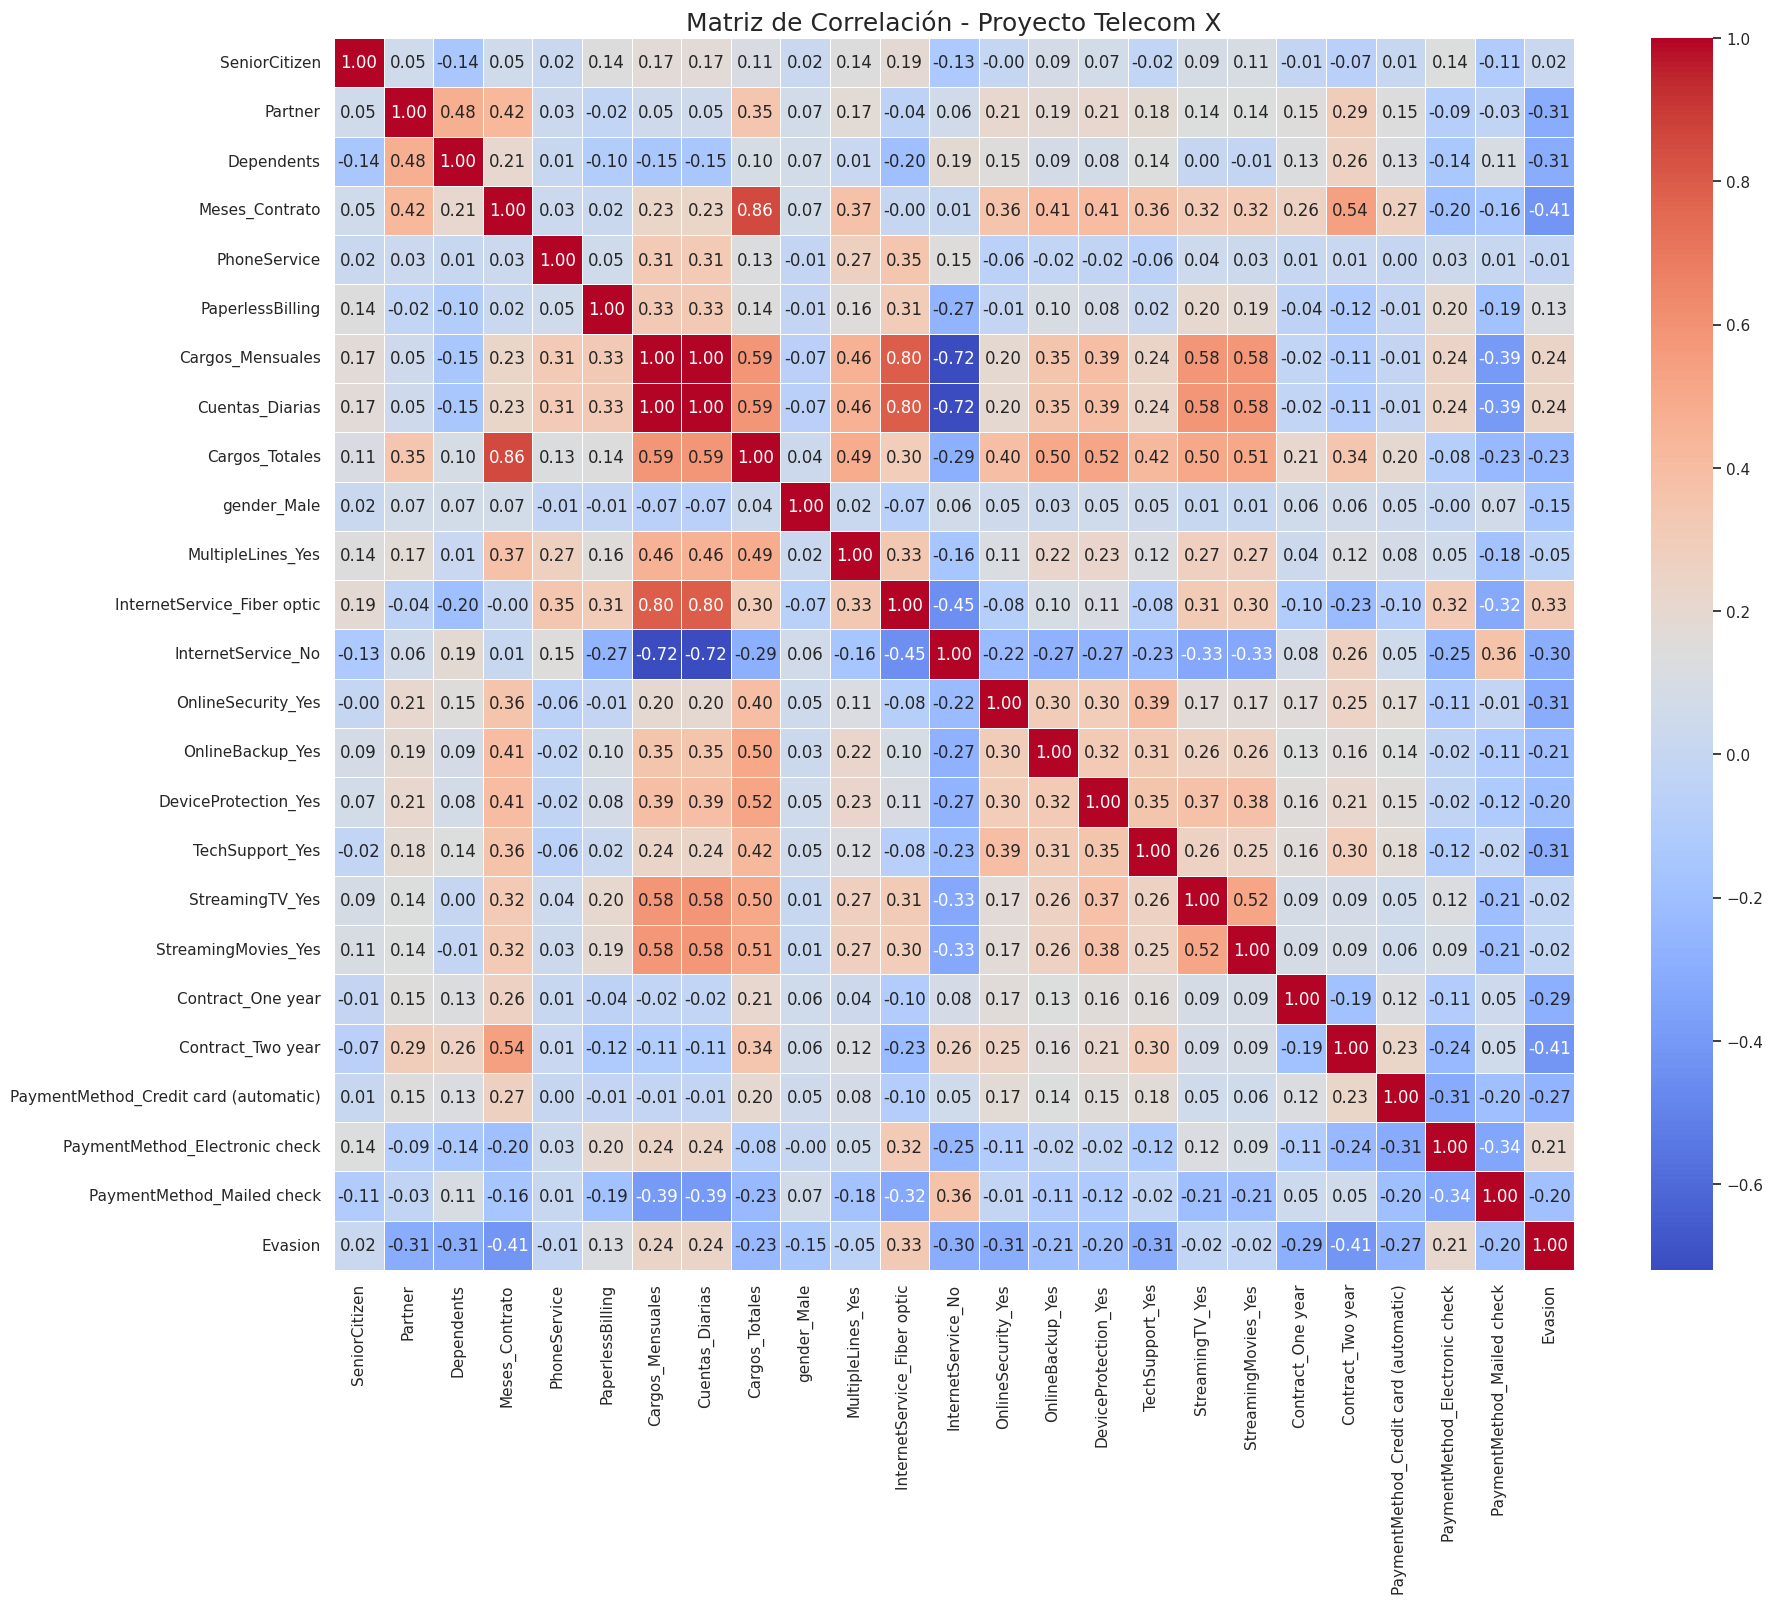


--- Top Variables correlacionadas con la Evasión ---
Evasion                                  1.000000
InternetService_Fiber optic              0.327297
Cuentas_Diarias                          0.235794
Cargos_Mensuales                         0.235719
PaymentMethod_Electronic check           0.211195
PaperlessBilling                         0.125708
SeniorCitizen                            0.019489
PhoneService                            -0.013040
StreamingTV_Yes                         -0.016935
StreamingMovies_Yes                     -0.019320
MultipleLines_Yes                       -0.051439
gender_Male                             -0.153763
PaymentMethod_Mailed check              -0.195283
DeviceProtection_Yes                    -0.200083
OnlineBackup_Yes                        -0.205717
Cargos_Totales                          -0.230041
PaymentMethod_Credit card (automatic)   -0.267995
Contract_One year                       -0.290215
InternetService_No                      -0.301

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular la matriz de correlación usando el DataFrame ya escalado
matriz_correlacion = df_telecom_escalado.corr()

# 2. Configurar el tamaño de la figura para que se vea claro (tenemos 25 columnas)
plt.figure(figsize=(20, 16))

# 3. Generar el Mapa de Calor (Heatmap)
# annot=True muestra los números, cmap='coolwarm' usa rojo para correlaciones positivas y azul para negativas
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación - Proyecto Telecom X', fontsize=18)
plt.show()

# 4. Extraer y ordenar específicamente la correlación de todas las variables frente a 'Evasion'
print("\n--- Top Variables correlacionadas con la Evasión ---")
correlacion_evasion = matriz_correlacion['Evasion'].sort_values(ascending=False)
print(correlacion_evasion)

## Análisis Dirigido

/tmp/ipykernel_293/1256563788.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Evasion', y='Meses_Contrato', data=df_telecom_balanceado, ax=axes[0], palette='Set2')
/tmp/ipykernel_293/1256563788.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Evasion', y='Cargos_Totales', data=df_telecom_balanceado, ax=axes[1], palette='Set2')


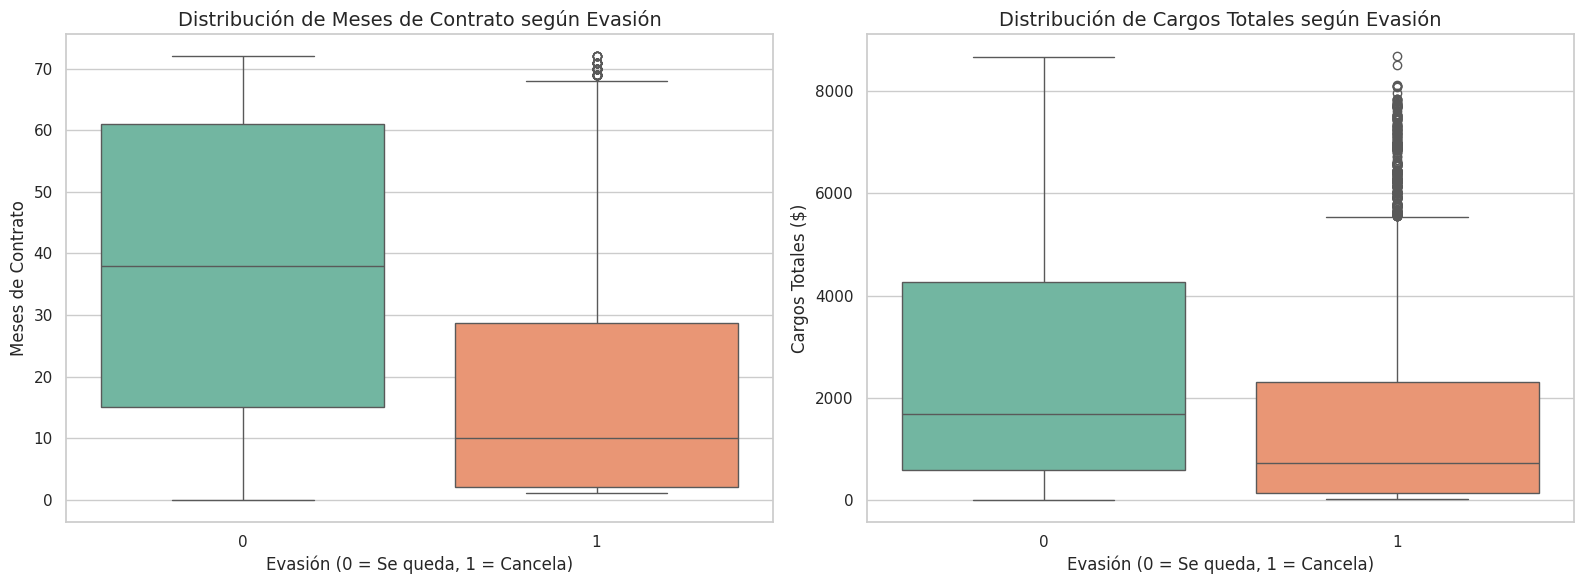

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo visual de los gráficos
sns.set_theme(style="whitegrid")

# Creamos un lienzo con 2 espacios para gráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico 1: Meses de Contrato vs Evasión ---
sns.boxplot(x='Evasion', y='Meses_Contrato', data=df_telecom_balanceado, ax=axes[0], palette='Set2')
axes[0].set_title('Distribución de Meses de Contrato según Evasión', fontsize=14)
axes[0].set_xlabel('Evasión (0 = Se queda, 1 = Cancela)', fontsize=12)
axes[0].set_ylabel('Meses de Contrato', fontsize=12)

# --- Gráfico 2: Cargos Totales vs Evasión ---
sns.boxplot(x='Evasion', y='Cargos_Totales', data=df_telecom_balanceado, ax=axes[1], palette='Set2')
axes[1].set_title('Distribución de Cargos Totales según Evasión', fontsize=14)
axes[1].set_xlabel('Evasión (0 = Se queda, 1 = Cancela)', fontsize=12)
axes[1].set_ylabel('Cargos Totales ($)', fontsize=12)

# Ajustamos el diseño para que no se superpongan y mostramos
plt.tight_layout()
plt.show()

#📌 Modelado Predictivo

## Separación de Datos

In [24]:
from sklearn.model_selection import train_test_split

# 1. Separar las características predictoras (X) de la variable objetivo a predecir (y)
X = df_telecom_escalado.drop('Evasion', axis=1)
y = df_telecom_escalado['Evasion']

# 2. Dividir los datos (80% entrenamiento, 20% prueba)
# random_state=42 asegura que siempre obtengas exactamente la misma división si vuelves a ejecutar el código
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. Confirmar las dimensiones de los nuevos conjuntos
print("--- Dimensiones de los conjuntos de datos ---")
print(f"Entrenamiento (X_train): {X_train.shape[0]} filas y {X_train.shape[1]} columnas")
print(f"Prueba (X_test): {X_test.shape[0]} filas y {X_test.shape[1]} columnas")

--- Dimensiones de los conjuntos de datos ---
Entrenamiento (X_train): 8278 filas y 24 columnas
Prueba (X_test): 2070 filas y 24 columnas


## Creación de Modelos

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Instanciar los modelos (llamar a los algoritmos)
# Utilizamos random_state=42 para que los resultados sean siempre reproducibles
modelo_logistico = LogisticRegression(random_state=42)
modelo_rf = RandomForestClassifier(random_state=42)

# 2. Entrenar los modelos con los datos de entrenamiento
print("Entrenando modelo de Regresión Logística...")
modelo_logistico.fit(X_train, y_train)
print("¡Regresión Logística entrenada exitosamente!\n")

print("Entrenando modelo de Random Forest...")
modelo_rf.fit(X_train, y_train)
print("¡Random Forest entrenado exitosamente!\n")

print("--- Ambos modelos están listos para ser evaluados ---")

Entrenando modelo de Regresión Logística...
¡Regresión Logística entrenada exitosamente!

Entrenando modelo de Random Forest...
¡Random Forest entrenado exitosamente!

--- Ambos modelos están listos para ser evaluados ---


## Evaluación de los Modelos

--- Resultados para: Regresión Logística ---
Exactitud (Accuracy) en Entrenamiento : 0.8323
Exactitud (Accuracy) en Prueba        : 0.8271
Precisión                             : 0.8271
Recall                                : 0.8303
F1-score                              : 0.8287



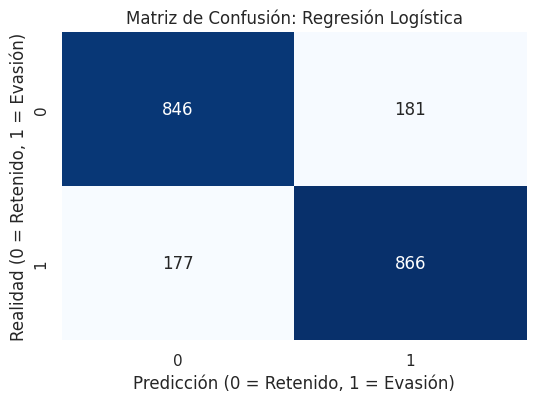

--- Resultados para: Random Forest ---
Exactitud (Accuracy) en Entrenamiento : 0.9986
Exactitud (Accuracy) en Prueba        : 0.8430
Precisión                             : 0.8452
Recall                                : 0.8428
F1-score                              : 0.8440



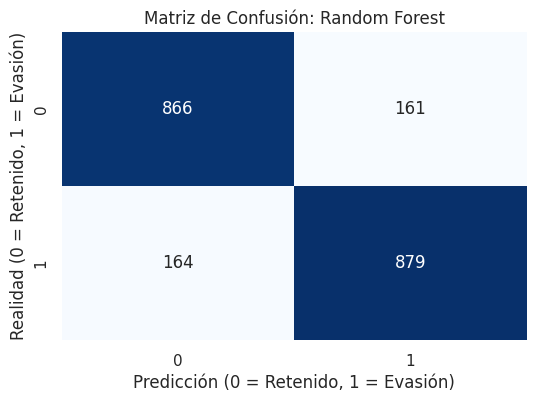

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Creamos una función para no repetir código y evaluar ambos modelos fácilmente
def evaluar_modelo(modelo, nombre, X_train, y_train, X_test, y_test):
    # 1. Generar las predicciones
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    # 2. Calcular las métricas solicitadas usando los datos de prueba (Test)
    acc_test = accuracy_score(y_test, y_pred_test)
    prec = precision_score(y_test, y_pred_test)
    rec = recall_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)

    # Calculamos Exactitud en Train para detectar Overfitting/Underfitting
    acc_train = accuracy_score(y_train, y_pred_train)

    # 3. Imprimir los resultados
    print(f"--- Resultados para: {nombre} ---")
    print(f"Exactitud (Accuracy) en Entrenamiento : {acc_train:.4f}")
    print(f"Exactitud (Accuracy) en Prueba        : {acc_test:.4f}")
    print(f"Precisión                             : {prec:.4f}")
    print(f"Recall                                : {rec:.4f}")
    print(f"F1-score                              : {f1:.4f}\n")

    # 4. Generar la Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred_test)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusión: {nombre}')
    plt.ylabel('Realidad (0 = Retenido, 1 = Evasión)')
    plt.xlabel('Predicción (0 = Retenido, 1 = Evasión)')
    plt.show()

# Ejecutamos la función para nuestros dos modelos
evaluar_modelo(modelo_logistico, "Regresión Logística", X_train, y_train, X_test, y_test)
evaluar_modelo(modelo_rf, "Random Forest", X_train, y_train, X_test, y_test)

#📄Interpretación y Conclusiones

## Análisis de la Importancia de las Variables

/tmp/ipykernel_293/4008534760.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variable', data=importancia_lr.head(10), ax=axes[0], palette='coolwarm')
/tmp/ipykernel_293/4008534760.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=importancia_rf.head(10), ax=axes[1], palette='viridis')


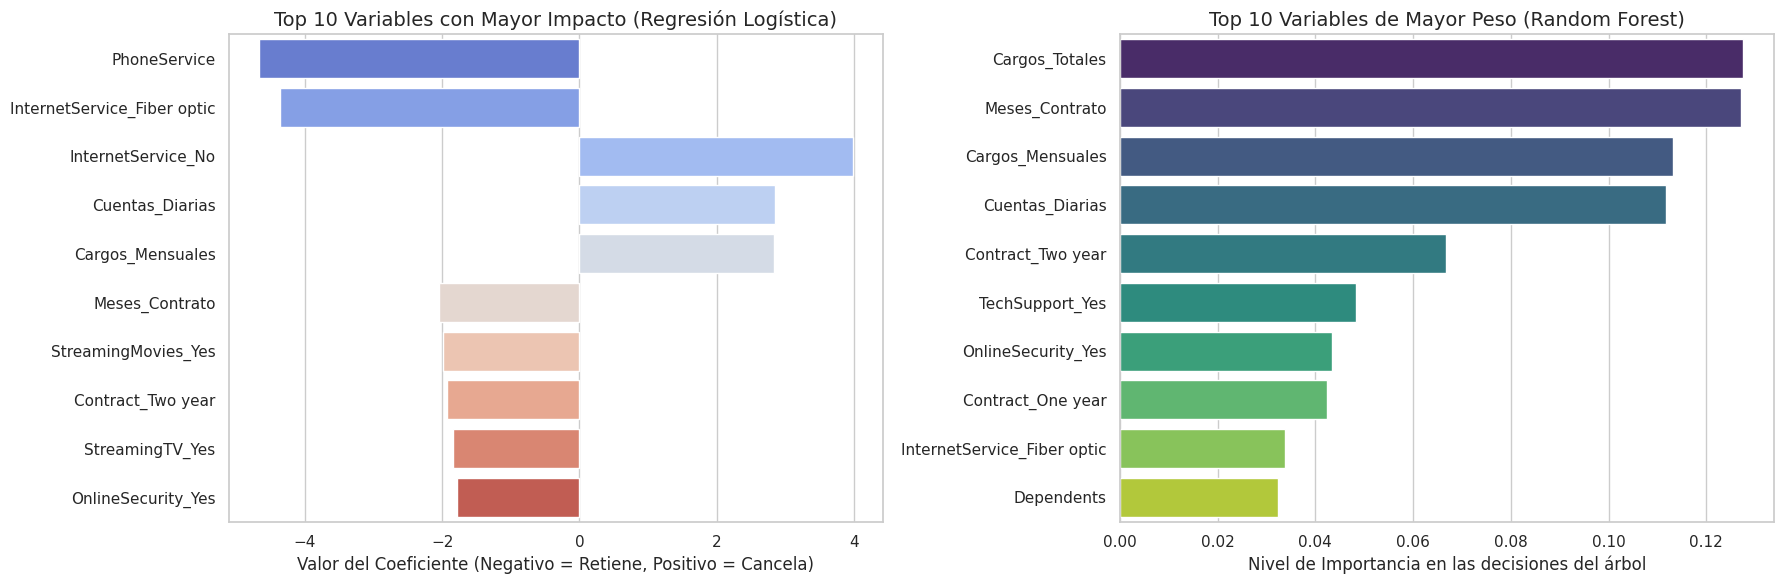

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Obtener los nombres de las columnas que se uso para entrenar
nombres_variables = X_train.columns

# 2. Extraer importancia de Regresión Logística (Coeficientes)
# Usamos el valor absoluto para encontrar los que tienen mayor impacto (sea positivo o negativo)
importancia_lr = pd.DataFrame({
    'Variable': nombres_variables,
    'Coeficiente': modelo_logistico.coef_[0],
    'Impacto_Absoluto': np.abs(modelo_logistico.coef_[0])
}).sort_values(by='Impacto_Absoluto', ascending=False)

# 3. Extraer importancia de Random Forest (Feature Importances)
importancia_rf = pd.DataFrame({
    'Variable': nombres_variables,
    'Importancia': modelo_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# 4. Configurar la visualización (2 gráficos lado a lado)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.set_theme(style="whitegrid")

# Gráfico A: Regresión Logística
sns.barplot(x='Coeficiente', y='Variable', data=importancia_lr.head(10), ax=axes[0], palette='coolwarm')
axes[0].set_title('Top 10 Variables con Mayor Impacto (Regresión Logística)', fontsize=14)
axes[0].set_xlabel('Valor del Coeficiente (Negativo = Retiene, Positivo = Cancela)')
axes[0].set_ylabel('')

# Gráfico B: Random Forest
sns.barplot(x='Importancia', y='Variable', data=importancia_rf.head(10), ax=axes[1], palette='viridis')
axes[1].set_title('Top 10 Variables de Mayor Peso (Random Forest)', fontsize=14)
axes[1].set_xlabel('Nivel de Importancia en las decisiones del árbol')
axes[1].set_ylabel('')

# Mostrar los gráficos limpios
plt.tight_layout()
plt.show()

## **Conclusión**

### **Informe Final**:

#### **Análisis de Evasión de Clientes (Churn) y Recomendaciones Estratégicas**

**1. Rendimiento de los Modelos Predictivos**

Se entrenaron y evaluaron dos modelos predictivos para identificar a los clientes en riesgo: **Regresión Logística** y **Random Forest**.

La **Regresión Logística** demostró ser el modelo más estable y confiable para este caso de negocio. Logró una precisión general de ~83% manteniendo un rendimiento muy equitativo entre el entrenamiento y la prueba, demostrando una excelente capacidad de generalización.

Por otro lado, aunque el **Random Forest** obtuvo métricas ligeramente superiores en las pruebas (F1-score de ~84%), presentó un claro problema de sobreajuste (overfitting), memorizando casi el 100% de los datos de entrenamiento. Por lo tanto, sin una optimización de hiperparámetros (como limitar la profundidad de los árboles), la Regresión Logística es la opción recomendada para su puesta en producción.

**2. Principales Factores que Influyen en la Cancelación**

Al extraer la importancia de las variables (Feature Importance y Coeficientes) de ambos algoritmos, convergen tres grandes focos de riesgo:

**Servicio de Internet por Fibra Óptica**: Es la variable individual que más empuja a los clientes a abandonar la empresa. Representa un punto crítico de insatisfacción.

**El Ciclo de Vida (Antigüedad / Meses de Contrato)**: Existe un alto riesgo de abandono durante la primera etapa del cliente en la empresa. Sin embargo, los clientes que firman contratos de uno o dos años, o que acumulan una mayor antigüedad, tienen una tasa de retención excepcionalmente alta.

**Sensibilidad al Costo**: Variables como los cargos mensuales y diarios influyen fuertemente; a mayores cobros, mayor es la probabilidad de que el cliente decida darse de baja.

**3. Estrategias de Retención Propuestas**

Basados en el análisis predictivo, se recomiendan a la gerencia las siguientes líneas de acción:

**Auditoría Técnica y Comercial a la Fibra Óptica**: Es urgente investigar qué está fallando con este servicio. Se debe evaluar si existen cortes constantes, si la velocidad entregada no es la prometida o si el precio está fuera de mercado en comparación con la competencia.

**Incentivar la Contratación a Largo Plazo**: Dado que los primeros meses son críticos, se sugiere ofrecer descuentos atractivos, meses de gracia o beneficios de bienvenida a cambio de que el cliente firme contratos cerrados de 1 o 2 años. Al lograr que crucen esa "zona de riesgo", la probabilidad de fuga cae drásticamente.

**Paquetes de Fidelización (Bundling)**: Considerando la sensibilidad al precio y que carecer de múltiples servicios aumenta la fuga, se propone crear paquetes (bundles). Ofrecer servicios adicionales (como PhoneService o OnlineSecurity) a un costo marginal reducido puede disminuir la percepción de estar pagando un cargo mensual alto, anclando al cliente al ecosistema de la empresa.